In [4]:
# Imports
import os
import sys
from IPython.display import display
from py_scripts.music_utils import parse_files

# Configuration
FILTER_ZERO_DURATION = True
ADJUST_FRACTIONAL_DURATION = True
PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'
SHOW_MEASURE_LINES = True   # draw red vertical lines at measure starts

DISPLAY_PREVIEW = True      # show a preview of the parsed data as df
PREVIEW_ROWS = 20          # number of rows to show in the preview

CLEANUP_REMOTE = True       # if source is a URL, delete temp file after parsing
RETURN_PLOTS = False        # include plot objects in results under 'plot'

# List of file sources (URLs or local paths)
FILE_SOURCES = [
    'https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn',
    'https://raw.githubusercontent.com/music-encoding/sample-encodings/main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei',
    'https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc2f05.krn',
]

# Plot sizing
PLOT_SIZE_X = 900  # width in pixels
PLOT_SIZE_Y = 600   # height in pixels

# Zoom tool dimensions: 'both' | 'width' (x-only) | 'height' (y-only)
# Bokeh only!
ZOOM_DRAG_DIM = 'both'
ZOOM_WHEEL_DIM = 'width'

# Parse and visualize
results, dfs_by_name, df_processed = parse_files(
    FILE_SOURCES,
    filter_zero_duration=FILTER_ZERO_DURATION,
    adjust_fractional_duration=ADJUST_FRACTIONAL_DURATION,
    backend=PLOTTING_BACKEND,
    show_measure_lines=SHOW_MEASURE_LINES,
    display_preview=DISPLAY_PREVIEW,
    preview_rows=PREVIEW_ROWS,
    cleanup_remote=CLEANUP_REMOTE,
    return_plots=RETURN_PLOTS,
    plot_width=PLOT_SIZE_X,
    plot_height=PLOT_SIZE_Y,
    zoom_drag_dim=ZOOM_DRAG_DIM,
    zoom_wheel_dim=ZOOM_WHEEL_DIM,
)

# Show quick summary
print('Parsed DataFrames:')
for item in results:
    name = item['name']
    df = item['df']
    pos_dur = df.loc[df['Duration'] > 0, 'Duration'] if 'Duration' in df.columns else None
    min_dur_str = str(float(pos_dur.min())) if pos_dur is not None and len(pos_dur) > 0 else 'n/a'
    print(f"- {name}: rows={len(df)}, unique_pitches={df['MIDI'].nunique()}, min_duration={min_dur_str}")


Parsing files:   0%|          | 0/3 [00:00<?, ?file/s]

Processing: wtc1f04.krn -> 00_wtc1f04


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice
0,1,0.0,0.0,4.0,C#3,49,spine_0
1,2,0.0,4.0,2.0,B#2,48,spine_0
2,2,2.0,6.0,2.0,E3,52,spine_0
3,3,0.0,8.0,4.0,D#3,51,spine_0
4,4,0.0,12.0,4.0,G#3,56,spine_0
5,4,0.0,12.0,1.0,C#3,49,spine_0
6,4,1.0,13.0,1.0,D#3,51,spine_0
7,4,2.0,14.0,2.0,E3,52,spine_0
8,5,0.0,16.0,2.0,F##3,55,spine_0
9,5,0.0,16.0,1.0,E3,52,spine_0


Rows: 1429, unique pitches: 45
Processing: Bach-JS_Ein_feste_Burg.mei -> 01_bach_js_ein_feste_burg


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice
0,0,0.0,0.0,1.0,D5,74,2201167490960 / Voice 1
1,0,0.0,0.0,1.0,A4,69,2201167490960 / Voice 2
2,0,0.0,0.0,1.0,F4,65,2201167490960 / Voice 1
3,0,0.0,0.0,0.5,D4,62,2201167490960 / Voice 2
4,0,0.5,0.5,0.5,C4,60,2201167490960 / Voice 2
5,1,0.0,1.0,1.0,D5,74,2201167490960 / Voice 1
6,1,0.0,1.0,1.0,D4,62,2201167490960 / Voice 2
7,1,0.0,1.0,1.0,F4,65,2201167490960 / Voice 1
8,1,0.0,1.0,1.0,B3,59,2201167490960 / Voice 2
9,1,1.0,2.0,1.0,D5,74,2201167490960 / Voice 1


Rows: 236, unique pitches: 25
Processing: wtc2f05.krn -> 02_wtc2f05


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice
0,1,0.5,0.5,0.5,D4,62,spine_0
1,1,1.0,1.0,0.5,D4,62,spine_0
2,1,1.5,1.5,0.5,D4,62,spine_0
3,1,2.0,2.0,1.0,G3,55,spine_0
4,1,3.0,3.0,1.0,B3,59,spine_0
5,2,0.0,4.0,0.5,B3,59,spine_0
6,2,0.5,4.5,0.5,E3,52,spine_0
7,2,1.0,5.0,0.5,A3,57,spine_0
8,2,1.5,5.5,0.5,G3,55,spine_0
9,2,2.0,6.0,1.0,F#3,54,spine_0


Rows: 969, unique pitches: 39
Parsed DataFrames:
- 00_wtc1f04: rows=1429, unique_pitches=45, min_duration=0.5
- 01_bach_js_ein_feste_burg: rows=236, unique_pitches=25, min_duration=0.25
- 02_wtc2f05: rows=969, unique_pitches=39, min_duration=0.25


In [5]:
list(dfs_by_name)

['00_wtc1f04', '01_bach_js_ein_feste_burg', '02_wtc2f05']

In [6]:
df1 = results[1]['df']
measure_offsets0 = results[0]['measure_offsets']

display(df1)

,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice
0,0,0.0,0.0,1.0,D5,74,2201167490960 / Voice 1
1,0,0.0,0.0,1.0,A4,69,2201167490960 / Voice 2
2,0,0.0,0.0,1.0,F4,65,2201167490960 / Voice 1
3,0,0.0,0.0,0.5,D4,62,2201167490960 / Voice 2
4,0,0.5,0.5,0.5,C4,60,2201167490960 / Voice 2
...,...,...,...,...,...,...,...
231,13,1.5,46.5,0.5,G3,55,2201167490960 / Voice 1
232,13,2.0,47.0,1.0,F3,53,2201167490960 / Voice 1
233,13,2.0,47.0,1.0,D4,62,2201167490960 / Voice 1
234,13,2.0,47.0,1.0,A3,57,2201167490960 / Voice 2


In [7]:
# Binary conversion and visualization (refactored to py_scripts)
import numpy as np
import pandas as pd
from py_scripts.music_utils import create_binary_matrix, plot_binary_matrix

# Configuration
BINARY_RESOLUTION_METHOD = 'manual'   # 'auto' | 'manual' | 'standard'
BINARY_MANUAL_RES = 0.5            # e.g., 0.5 when using 'manual'
Y_AXIS_MODE = 'full'              # 'full' | 'minmax' | 'chroma'
Y_AXIS_MIN = 60                   # optional int when Y_AXIS_MODE=='minmax'
Y_AXIS_MAX = 71                   # optional int when Y_AXIS_MODE=='minmax'

PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'

# Build binary matrix
binary_matrix_df, meta = create_binary_matrix(
    df1,
    resolution_method=BINARY_RESOLUTION_METHOD,
    manual_resolution=BINARY_MANUAL_RES,
    y_mode=Y_AXIS_MODE,
    midi_low=Y_AXIS_MIN,
    midi_high=Y_AXIS_MAX,
    row_order="high_to_low"
)

print(f"Binary matrix shape: {binary_matrix_df.shape}")
print(f"Resolution: {meta['resolution']}, columns: {meta['num_cols']}, y_mode: {meta['y_mode']}")

# Plot using the same backend as parsing cell (if defined), else default to 'plt'
backend_to_use = PLOTTING_BACKEND

# If measure offsets were computed earlier, you can pass them here.
# In this notebook, measure offsets are inside `results` items if needed; we default to None
plot_binary_matrix(
    binary_matrix_df,
    meta,
    backend=backend_to_use,
    measure_offsets=None,
    show_measure_lines=True,
    show=True,
    plot_width=1200, plot_height=800, dpi=100,
    zoom_drag_dim="both", zoom_wheel_dim="width",
    pitch_labels=True,
    save_html=False,
    # save_html_path="binary_matrix.html",
    # save_png_path="binary_matrix.png",
    # open_html_after_save=True,
)

Binary matrix shape: (128, 98)
Resolution: 0.5, columns: 98, y_mode: full


figure(id='p1666', ...)

In [8]:
print(binary_matrix_df)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
from py_scripts.binary_matrix_designer import binary_matrix_designer

# Start with an empty 12x12 grid with pitch names enabled
ui = binary_matrix_designer(
    rows=12,
    cols=12,
    # prototype=None,        # default
    # prototype_meta=None,   # default
    flip_vertical=True,
    display_ui=True         # or False + display(ui)
)

# The pitch names checkbox is now integrated into the "Matrix Setup" section!
# - Check "Show pitch names" to display C, C#, D, D#, E, F, F#, G, G#, A, A#, B
# - The bottom row shows "C", and it cycles through the chromatic scale
# - Uncheck to hide the pitch names
# - Located in the Matrix Setup section below the main controls


In [11]:
print(binary_matrix_ui)

[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


In [12]:
# Convert a binary matrix back into a notes DataFrame and sanity-check round trip
import numpy as np
import pandas as pd
from py_scripts.music_utils import (
    binary_matrix_to_df_from_bounds,
)

# Derive a DataFrame from the UI/exported binary matrix
# - binary_matrix_ui: defined by the interactive editor above
# - resolution: grid size (quarterLength units)
# - midi_low: lowest MIDI in the view (bottom row when flipped=True)
df_ui = binary_matrix_to_df_from_bounds(
    binary_matrix_ui,
    resolution=0.5,
    midi_low=60,
    flipped=True,
)

print(df_ui)

   MIDI  Global Onset  Duration
0    61           0.0       0.5
1    61           1.0       0.5
2    61           2.5       1.0
3    65           2.5       0.5
4    69           3.5       0.5
5    65           4.0       0.5
6    67           5.0       0.5


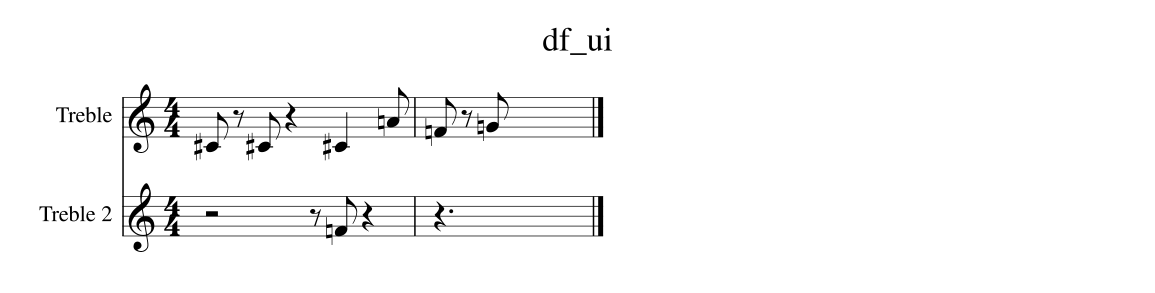

Rendered 1 page(s). Variables available: MEI_LAST, MUSICXML_LAST.


In [13]:
from py_scripts.music21_render import (
    df_to_music21,
    music21_to_musicxml_string,
    render_with_verovio_from_musicxml,
)

# Example: render df_ui (created above). If not present, fall back to a tiny demo
target_df = df_ui
target_df_name = 'df_ui'

for name, value in list(globals().items()):
    if value is target_df and name not in {'target_df', 'target_df_name'}:
        target_df_name = name
        break

score = df_to_music21(
    target_df,
    time_signature='4/4',
    unit_quarter_length=1.0,
    piece_title=target_df_name,
    clef_config='AUTO', # 'G', 'F', 'GF', or 'AUTO'
    split_midi=59,
    voices_per_stave=1,  # 1 or 2
    enforce_accidentals=True,  # force naturals/sharps/flats to be shown
)
musicxml_str = music21_to_musicxml_string(score)
mei_str, svg_pages = render_with_verovio_from_musicxml(musicxml_str, scale=55)

# Expose strings for export if needed
MEI_LAST = mei_str
MUSICXML_LAST = musicxml_str
print(f"Rendered {len(svg_pages)} page(s). Variables available: MEI_LAST, MUSICXML_LAST.")


In [14]:
# Pattern search (refactored to py_scripts)
from py_scripts.pattern_search import run_pattern_search
import numpy as np
import pandas as pd

# Configuration
STRIDE_Y = 1
STRIDE_X = 1
TOP_N_MATCHES = 20
PLOT_THRESHOLDS = {
    'normalized_overlap': 0,
    'cross_covariance': None,
    'normalized_cross_correlation': None,
}
MPL_CMAP = 'viridis'

METRICS_TO_RUN = ['normalized_overlap']  # or include 'cross_covariance', 'normalized_cross_correlation'
KERNEL_SCALE_FACTORS = [0.5, 0.75, 1.0, 1.5, 2.0]
KERNEL_SCALE_AXES = ['x']  # 'x', 'y', or 'both'
PLOT_SCALED_KERNELS = False
BINARIZE_SCALED_KERNEL = True
BINARIZE_THRESHOLD = 0.5
SHARE_Y_SCALING = True

backend_to_use = globals().get('PLOTTING_BACKEND', 'plt')

# Preconditions
if 'binary_matrix_df' not in globals() or 'binary_matrix_ui' not in globals():
    raise NameError('Run previous cells to define binary_matrix_df and binary_matrix_ui.')

matrix_source = binary_matrix_df
kernel_candidate = binary_matrix_ui

print(f"Source binary_matrix_df shape: {np.asarray(matrix_source if not isinstance(matrix_source, pd.DataFrame) else matrix_source.values).shape}")
print(f"Base kernel shape: {np.asarray(kernel_candidate if not isinstance(kernel_candidate, pd.DataFrame) else kernel_candidate.values).shape}")
print(f"Stride (Y, X): ({STRIDE_Y}, {STRIDE_X})")
print('Metrics to run:', ', '.join(METRICS_TO_RUN))

# Execute refactored search
pattern_search_results, pattern_search_kernels, last_pattern_search_variant, conv_raw_df = run_pattern_search(
    matrix_source,
    kernel_candidate,
    metrics_to_run=METRICS_TO_RUN,
    stride_y=STRIDE_Y,
    stride_x=STRIDE_X,
    kernel_scale_factors=KERNEL_SCALE_FACTORS,
    kernel_scale_axes=KERNEL_SCALE_AXES,
    binarize_scaled_kernel=BINARIZE_SCALED_KERNEL,
    binarize_threshold=BINARIZE_THRESHOLD,
    share_y_scaling=SHARE_Y_SCALING,
    plot_thresholds=PLOT_THRESHOLDS,
    backend=backend_to_use,
    mpl_cmap=MPL_CMAP,
    plot_scaled_kernels=PLOT_SCALED_KERNELS,
    top_n_matches=TOP_N_MATCHES,
)

# Expose convenience variables
if last_pattern_search_variant is not None:
    last_metrics = pattern_search_results[last_pattern_search_variant]
    conv_norm_df = last_metrics.get('normalized_overlap')
    cross_cov_df = last_metrics.get('cross_covariance')
    norm_cross_df = last_metrics.get('normalized_cross_correlation')
else:
    conv_norm_df = None
    cross_cov_df = None
    norm_cross_df = None

print('Stored results in pattern_search_results; last variant key:', last_pattern_search_variant)


Source binary_matrix_df shape: (128, 98)
Base kernel shape: (12, 12)
Stride (Y, X): (1, 1)
Metrics to run: normalized_overlap


Normalised overlap best: 1.000 at top-left (row=53, col=8)
Normalised overlap top 20 positions:
  score=1.000 at row=65, col=42
  score=1.000 at row=65, col=41
  score=1.000 at row=72, col=43
  score=1.000 at row=72, col=44
  score=1.000 at row=60, col=54
  score=1.000 at row=60, col=53
  score=1.000 at row=53, col=8
  score=1.000 at row=65, col=12
  score=1.000 at row=60, col=52
  score=1.000 at row=72, col=62
  score=1.000 at row=66, col=70
  score=1.000 at row=60, col=55
  score=1.000 at row=60, col=46
  score=1.000 at row=65, col=40
  score=1.000 at row=58, col=70
  score=1.000 at row=72, col=28
  score=1.000 at row=72, col=92
  score=0.667 at row=52, col=1
  score=0.667 at row=52, col=2
  score=0.667 at row=65, col=8


Normalised overlap best: 0.667 at top-left (row=50, col=61)
Normalised overlap top 20 positions:
  score=0.667 at row=52, col=56
  score=0.667 at row=58, col=68
  score=0.667 at row=52, col=54
  score=0.667 at row=56, col=54
  score=0.667 at row=57, col=22
  score=0.667 at row=58, col=71
  score=0.667 at row=58, col=70
  score=0.667 at row=54, col=61
  score=0.667 at row=50, col=61
  score=0.667 at row=52, col=6
  score=0.500 at row=59, col=19
  score=0.500 at row=52, col=44
  score=0.500 at row=59, col=21
  score=0.500 at row=68, col=73
  score=0.500 at row=68, col=74
  score=0.500 at row=59, col=84
  score=0.500 at row=65, col=38
  score=0.500 at row=59, col=85
  score=0.500 at row=57, col=1
  score=0.500 at row=55, col=33


Normalised overlap best: 0.750 at top-left (row=52, col=6)
Normalised overlap top 20 positions:
  score=0.750 at row=52, col=55
  score=0.750 at row=52, col=54
  score=0.750 at row=52, col=6
  score=0.625 at row=64, col=30
  score=0.625 at row=65, col=36
  score=0.625 at row=58, col=70
  score=0.625 at row=58, col=66
  score=0.625 at row=52, col=51
  score=0.625 at row=55, col=31
  score=0.625 at row=65, col=38
  score=0.625 at row=50, col=59
  score=0.625 at row=52, col=1
  score=0.500 at row=55, col=2
  score=0.500 at row=52, col=10
  score=0.500 at row=55, col=83
  score=0.500 at row=50, col=61
  score=0.500 at row=50, col=62
  score=0.500 at row=53, col=13
  score=0.500 at row=62, col=67
  score=0.500 at row=60, col=47


Normalised overlap best: 0.615 at top-left (row=52, col=2)
Normalised overlap top 20 positions:
  score=0.615 at row=52, col=51
  score=0.615 at row=52, col=2
  score=0.615 at row=58, col=67
  score=0.615 at row=58, col=62
  score=0.615 at row=52, col=48
  score=0.615 at row=52, col=3
  score=0.538 at row=58, col=61
  score=0.538 at row=52, col=50
  score=0.538 at row=52, col=49
  score=0.538 at row=52, col=68
  score=0.538 at row=50, col=58
  score=0.538 at row=50, col=57
  score=0.538 at row=65, col=33
  score=0.538 at row=64, col=22
  score=0.538 at row=53, col=5
  score=0.462 at row=57, col=6
  score=0.462 at row=58, col=63
  score=0.462 at row=52, col=55
  score=0.462 at row=64, col=39
  score=0.462 at row=59, col=76


Normalised overlap best: 0.625 at top-left (row=55, col=20)
Normalised overlap top 20 positions:
  score=0.625 at row=55, col=20
  score=0.562 at row=52, col=44
  score=0.562 at row=58, col=58
  score=0.562 at row=52, col=0
  score=0.500 at row=60, col=42
  score=0.500 at row=52, col=45
  score=0.500 at row=52, col=46
  score=0.438 at row=52, col=64
  score=0.438 at row=52, col=58
  score=0.438 at row=70, col=74
  score=0.438 at row=52, col=1
  score=0.438 at row=52, col=65
  score=0.438 at row=52, col=66
  score=0.438 at row=65, col=8
  score=0.438 at row=50, col=54
  score=0.438 at row=53, col=4
  score=0.438 at row=58, col=57
  score=0.438 at row=61, col=12
  score=0.438 at row=64, col=18
  score=0.438 at row=52, col=43
Stored results in pattern_search_results; last variant key: axis=x, factor=2, scale_y=1.000, scale_x=2.000


In [16]:
print(pattern_search_results)

{'axis=x, factor=0.5, scale_y=1.000, scale_x=0.500': {'normalized_overlap':       0    1    2    3    4    5    6    7    8    9   ...   83   84   85  \
0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
112  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
113  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
114  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
115  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
116  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   


In [17]:
# Overlay top convolution matches on the piano roll (refactored)
import numpy as np
import pandas as pd
from IPython.display import display
from bokeh.palettes import Viridis256

from py_scripts import (
    select_metric_df,
    kernel_from_variants,
    overlay_top_matches_on_piano_roll,
)

# Preconditions: results from pattern search and binary conversion must exist
if 'pattern_search_results' not in globals():
    raise NameError('Run the pattern search cell first to populate pattern_search_results.')
if 'pattern_search_kernels' not in globals():
    raise NameError('Run the pattern search cell to populate pattern_search_kernels.')
if 'meta' not in globals():
    raise NameError('Binary matrix metadata meta is unavailable. Run the binary conversion cell.')
if 'df' not in globals():
    raise NameError('Notes DataFrame df is unavailable.')

# ----------------------------
# Configuration variables
# ----------------------------
# Variant and metric selection
overlay_variant_key = "axis=x, factor=0.5, scale_y=1.000, scale_x=0.500"  # None => use latest
overlay_metric_key = 'normalized_overlap'  # e.g., 'normalized_overlap', 'cross_covariance', 'normalized_cross_correlation'

# Top matches selection
overlay_top_n = 5
overlay_min_score = None          # e.g., 0.6 to filter low scores; or None
overlay_score_quantile = None     # e.g., 0.98 to keep top 2% by score; or None

# Rendering and styling
overlay_palette = Viridis256
overlay_fill_alpha = 0.25
overlay_plot_width = 1200
overlay_plot_height = 800
overlay_dpi = 100
overlay_zoom_drag_dim = 'both'
overlay_zoom_wheel_dim = 'width'
overlay_show = True

# Optional raw overlap DataFrame produced during search (if available)
conv_raw_df = globals().get('conv_raw_df')

# ----------------------------
# Metric and kernel selection
# ----------------------------
variant_key, conv_df = select_metric_df(pattern_search_results, overlay_metric_key, variant_key=overlay_variant_key)

# Choose a default kernel if the variant is missing from pattern_search_kernels
_default_kernel = globals().get('binary_matrix_ui')
if _default_kernel is None:
    _default_kernel = globals().get('binary_matrix_df')
kernel_source = kernel_from_variants(pattern_search_kernels, variant_key, _default_kernel)

# ----------------------------
# Render overlay and show matches
# ----------------------------
p_overlay, df_matches = overlay_top_matches_on_piano_roll(
    df_notes=df,
    conv_df=conv_df,
    kernel_source=kernel_source,
    meta=meta,
    measure_offsets=measure_offsets if 'measure_offsets' in globals() else None,
    top_n=int(overlay_top_n),
    min_score=overlay_min_score,
    score_quantile=overlay_score_quantile,
    palette=overlay_palette,
    fill_alpha=overlay_fill_alpha,
    plot_width=int(overlay_plot_width),
    plot_height=int(overlay_plot_height),
    dpi=float(overlay_dpi),
    zoom_drag_dim=str(overlay_zoom_drag_dim),
    zoom_wheel_dim=str(overlay_zoom_wheel_dim),
    conv_raw_df=conv_raw_df if isinstance(conv_raw_df, pd.DataFrame) else None,
    show=bool(overlay_show),
)

display(df_matches[[
    'rank', 'score_norm', 'score_raw', 'norm_value',
    'time_start', 'time_end', 'midi_low', 'midi_high', 'row_idx', 'col_idx',
]])

c:\Users\egorp\Nextcloud\code\public_repos\camat_v2\CAMAT_revamped\py_scripts\overlay.py:85: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  values.stack(dropna=True)


,rank,score_norm,score_raw,norm_value,time_start,time_end,midi_low,midi_high,row_idx,col_idx
0,1,1.0,5.0,1.0,4.0,7.0,63,74,53,8
1,2,1.0,2.0,1.0,22.0,25.0,44,55,72,44
2,3,1.0,5.0,1.0,23.0,26.0,56,67,60,46
3,4,1.0,4.0,1.0,35.0,38.0,50,61,66,70
4,5,1.0,2.0,1.0,31.0,34.0,44,55,72,62
